# 01 - EDA: Balance de clases del target

## 1. Descripción

Este notebook realiza el análisis exploratorio de datos (EDA) de `dataset_modelado_personas.csv` antes de la fase de Modelado: balance de la variable objetivo `satisfecho_democracia` (global, por año y valores faltantes), perfil sociodemográfico de los encuestados, evolución temporal de los indicadores macro (ENEMDU/V-Dem), correlación entre variables numéricas clave y el target, y relación de las variables categóricas más relevantes (según SHAP) con el target. Estos resultados fundamentan la estrategia de remuestreo (SMOTENC, aplicado solo sobre `X_train` después del split) usada en la fase de Modelado.

**Contenido de este notebook:**

1. Descripción
2. Importaciones
3. Configuración (carga de datos)
4. Análisis exploratorio de datos
   - 4.1 Balance global de la variable objetivo
   - 4.2 Balance por año de encuesta
   - 4.3 Valores faltantes por columna
   - 4.4 Conclusiones y decisión sobre SMOTENC
   - 4.5 Distribución demográfica de los encuestados
   - 4.6 Evolución temporal de los indicadores macro
   - 4.7 Correlación entre variables numéricas clave y el target
   - 4.8 Variables categóricas más relevantes (según SHAP) vs. el target
5. Resultados (conclusiones generales y decisiones para el pipeline)


## 2. Importaciones

In [1]:
# %run ejecuta 00_parametros_globales.ipynb en este kernel: fija semillas,
# detecta GPU y define las rutas del proyecto (RUTA_DATASET_PERSONAS, RUTA_FIGURES, etc.).
%run ./00_parametros_globales.ipynb

import matplotlib.pyplot as plt
import pandas as pd


GPU NVIDIA detectada: True
  Dispositivo: NVIDIA GeForce RTX 4090
RAIZ_PROYECTO: /home/daltamirano/democratic-satisfaction-ec
SAMPLING_MODE: False (fracción=1.0)
VENTANA_TEMPORAL_ANIOS: 3
RUTA_DATASET_PERSONAS existe: True
RUTA_PANEL_MACRO existe: True


## 3. Configuración

In [2]:
pd.set_option("display.width", 160)

df = pd.read_csv(RUTA_DATASET_PERSONAS)
print(f"Filas: {len(df)}  Columnas: {df.shape[1]}")
df.head()


Filas: 15600  Columnas: 71


,democ_satis,democ_supp,left_right_scale,job_concern,econ_situation,confidence_congress,confidence_judiciary,confidence_church,confidence_police,confidence_army,...,v2x_jucon,v2xlg_legcon,v2xeg_eqprotec,v2xeg_eqaccess,v2xeg_eqdr,v2pepwrses,v2pepwrsoc,v2pepwrgen,v2pepwrort,v2pepwrgeo
0,1.0,1.0,9.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,...,0.353,0.416,0.503,0.703,0.535,0.631375,0.63025,0.57875,0.46025,0.439
1,1.0,1.0,8.0,3.0,2.0,3.0,2.0,2.0,2.0,2.0,...,0.353,0.416,0.503,0.703,0.535,0.631375,0.63025,0.57875,0.46025,0.439
2,3.0,1.0,7.0,2.0,2.0,4.0,4.0,4.0,4.0,4.0,...,0.353,0.416,0.503,0.703,0.535,0.631375,0.63025,0.57875,0.46025,0.439
3,3.0,1.0,6.0,2.0,2.0,4.0,4.0,4.0,4.0,4.0,...,0.353,0.416,0.503,0.703,0.535,0.631375,0.63025,0.57875,0.46025,0.439
4,3.0,1.0,7.0,2.0,2.0,4.0,4.0,2.0,2.0,2.0,...,0.353,0.416,0.503,0.703,0.535,0.631375,0.63025,0.57875,0.46025,0.439


## 4. Análisis exploratorio de datos

### 4.1 Balance global de la variable objetivo

Balance global (%):
satisfecho_democracia
0.0    59.31
1.0    37.48
NaN     3.21
Name: proportion, dtype: float64

Respuestas válidas: 15099/15600 (96.8%)
El resto (NaN) corresponde a encuestados con respuesta no válida en democ_satis (ver latinobarometro_processing.py) y se descarta antes de entrenar cualquier modelo.


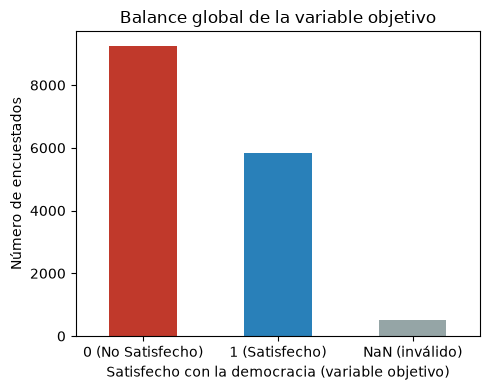

In [3]:
n_total = len(df)
n_validos = df["satisfecho_democracia"].notna().sum()
balance_global_pct = df["satisfecho_democracia"].value_counts(dropna=False, normalize=True) * 100

print("Balance global (%):")
print(balance_global_pct.round(2))
print(f"\nRespuestas válidas: {n_validos}/{n_total} ({100*n_validos/n_total:.1f}%)")
print(
    "El resto (NaN) corresponde a encuestados con respuesta no válida en democ_satis "
    "(ver latinobarometro_processing.py) y se descarta antes de entrenar cualquier modelo."
)

# Conteo con orden y etiquetas FIJAS (no por frecuencia): satisfecho_democracia es
# float64 porque la columna tiene NaN, así que value_counts().index traería 0.0/1.0
# (el eje mostraría "1.0" en vez de "1"). Se cuenta cada categoría explícitamente y
# se usan etiquetas de texto, evitando además que un cambio en las frecuencias
# desalinee las barras con los colores.
serie = df["satisfecho_democracia"]
conteo = pd.Series(
    [int((serie == 0).sum()), int((serie == 1).sum()), int(serie.isna().sum())],
    index=["0 (No Satisfecho)", "1 (Satisfecho)", "NaN (inválido)"],
)
fig, ax = plt.subplots(figsize=(5, 4))
conteo.plot(kind="bar", ax=ax, color=["#c0392b", "#2980b9", "#95a5a6"])
ax.set_title("Balance global de la variable objetivo")
# Nombre descriptivo en el eje X en vez del código crudo "satisfecho_democracia".
ax.set_xlabel("Satisfecho con la democracia (variable objetivo)")
ax.set_ylabel("Número de encuestados")
plt.setp(ax.get_xticklabels(), rotation=0)
fig.tight_layout()
fig.savefig(RUTA_FIGURES / "balance_global_target.png", dpi=120)
plt.show()


### 4.2 Balance por año de encuesta

Esta es la vista que más importa para decidir SMOTENC: si el desbalance varía fuertemente entre años, aplicar SMOTENC de forma global (sin considerar el año) podría distorsionar la estructura temporal que el CNN-LSTM necesita aprender. Conviene revisar esto ANTES de fijar la estrategia de remuestreo.

Tasa de 'Satisfecho' (%) y tamaño de muestra por año:
      tasa_satisfaccion     n
anio                         
2007              36.03  1149
2008              39.53  1113
2009              35.95  1107
2010              50.43  1158
2011              49.83  1168
2013              61.24  1161
2015              59.63  1174
2016              41.99  1174
2017              51.65  1183
2018              36.54  1166
2020              10.14  1164
2023              11.97  1186
2024              19.06  1196

Año con MENOR tasa de satisfacción: 2020 (10.14%)
Año con MAYOR tasa de satisfacción: 2013 (61.24%)


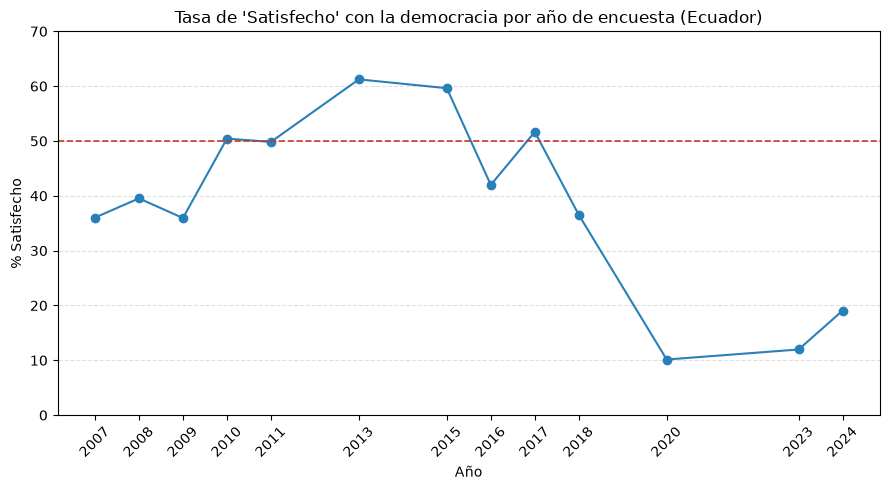

In [4]:
balance_por_anio = (
    df.dropna(subset=["satisfecho_democracia"])
      .groupby("anio")["satisfecho_democracia"]
      .agg(tasa_satisfaccion="mean", n="count")
)
balance_por_anio["tasa_satisfaccion"] = (balance_por_anio["tasa_satisfaccion"] * 100).round(2)
print("Tasa de 'Satisfecho' (%) y tamaño de muestra por año:")
print(balance_por_anio)

anio_min = balance_por_anio["tasa_satisfaccion"].idxmin()
anio_max = balance_por_anio["tasa_satisfaccion"].idxmax()
print(
    f"\nAño con MENOR tasa de satisfacción: {anio_min} "
    f"({balance_por_anio.loc[anio_min, 'tasa_satisfaccion']}%)"
)
print(
    f"Año con MAYOR tasa de satisfacción: {anio_max} "
    f"({balance_por_anio.loc[anio_max, 'tasa_satisfaccion']}%)"
)

fig, ax = plt.subplots(figsize=(9, 5))
balance_por_anio["tasa_satisfaccion"].plot(kind="line", marker="o", ax=ax, color="#2980b9")
# Línea de referencia en 50% (mayoría/minoría) resaltada en rojo, más las líneas de
# cuadrícula del eje Y cada 10 puntos (más tenues) para poder leer cualquier año sin
# tener que interpolar visualmente contra un único punto de referencia.
ax.axhline(50, color="#c0392b", linestyle="--", linewidth=1.2, label="50%")
ax.set_yticks(range(0, 71, 10))
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.set_title("Tasa de 'Satisfecho' con la democracia por año de encuesta (Ecuador)")
ax.set_xlabel("Año")
ax.set_ylabel("% Satisfecho")
# Los años de encuesta tienen huecos (no todos los años tienen ola de Latinobarómetro),
# así que se fijan los ticks a los años reales presentes en los datos -- si no, el
# locator automático de matplotlib puede mostrar años intermedios "redondeados"
# (ej. 2007.5, 2012.5) que no corresponden a ninguna encuesta real.
ax.set_xticks(balance_por_anio.index)
ax.set_xticklabels(balance_por_anio.index, rotation=45)
fig.tight_layout()
fig.savefig(RUTA_FIGURES / "tasa_satisfaccion_por_anio.png", dpi=120)
plt.show()

### 4.3 Valores faltantes por columna

Revisión rápida de calidad de datos antes de decidir imputación/exclusión de variables para el modelado (más allá de lo ya tratado en Fase 2).

% de valores faltantes por columna (solo columnas con al menos 1 faltante):
econ_situation_cat                    0.33
econ_situation                        0.33
goods_wash_mach                       0.38
goods_wash_mach_bin                   0.38
goods_sewage                          0.48
goods_sewage_bin                      0.48
goods_hot_water                       0.53
goods_hot_water_bin                   0.53
confidence_police_alta                0.56
confidence_police                     0.56
goods_car_bin                         0.67
goods_car                             0.67
confidence_church                     0.93
confidence_church_alta                0.93
job_concern                           1.19
confidence_army_alta                  1.20
confidence_army                       1.20
confidence_congress                   1.75
confidence_congress_alta              1.75
confidence_political_parties_alta     1.90
confidence_political_parties          1.90
confidence_judiciary 

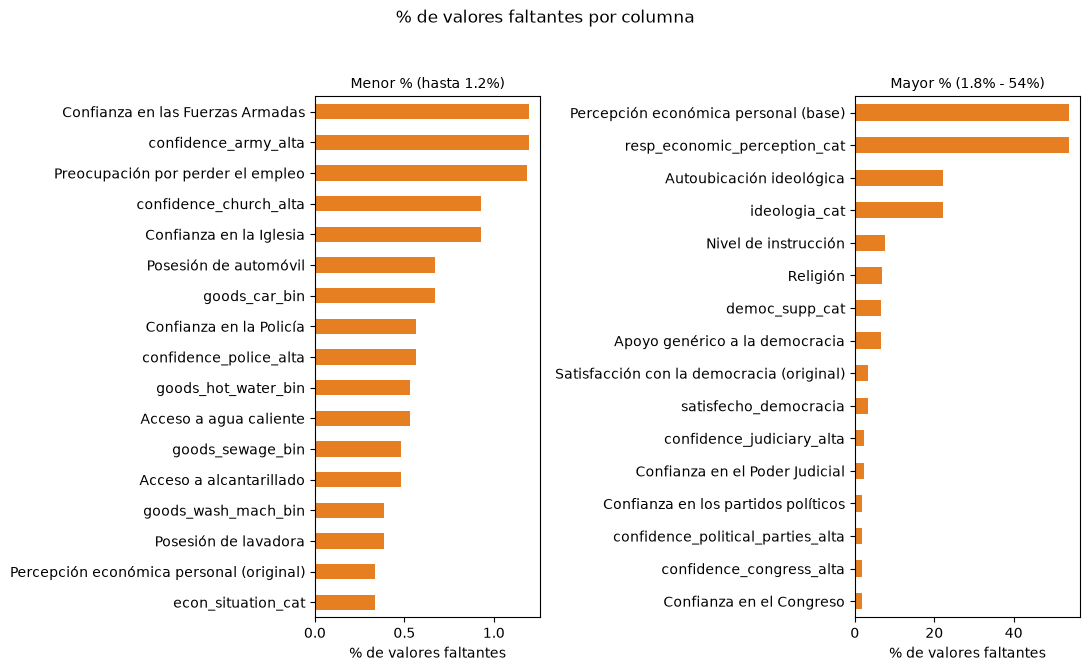

In [5]:
# Diccionario de nombres descriptivos para las columnas del dataset (evita mostrar
# códigos crudos en los ejes de los gráficos, por recomendación del tutor).
NOMBRES_COLUMNAS = {
    "democ_satis": "Satisfacción con la democracia (original)",
    "democ_supp": "Apoyo genérico a la democracia",
    "left_right_scale": "Autoubicación ideológica",
    "job_concern": "Preocupación por perder el empleo",
    "econ_situation": "Percepción económica personal (original)",
    "confidence_congress": "Confianza en el Congreso",
    "confidence_judiciary": "Confianza en el Poder Judicial",
    "confidence_church": "Confianza en la Iglesia",
    "confidence_police": "Confianza en la Policía",
    "confidence_army": "Confianza en las Fuerzas Armadas",
    "confidence_political_parties": "Confianza en los partidos políticos",
    "resp_sex": "Sexo (código Latinobarómetro)",
    "resp_age": "Edad",
    "resp_education": "Nivel de instrucción",
    "resp_employment": "Situación laboral",
    "resp_religion": "Religión",
    "goods_wash_mach": "Posesión de lavadora",
    "goods_car": "Posesión de automóvil",
    "goods_sewage": "Acceso a alcantarillado",
    "goods_hot_water": "Acceso a agua caliente",
    "resp_chief": "Jefatura de hogar",
    "resp_economic_perception": "Percepción económica personal (base)",
}

faltantes = (df.isna().mean() * 100).sort_values(ascending=True)
faltantes = faltantes[faltantes > 0]
print("% de valores faltantes por columna (solo columnas con al menos 1 faltante):")
print(faltantes.round(2))

if len(faltantes):
    faltantes_legible = faltantes.copy()
    faltantes_legible.index = [NOMBRES_COLUMNAS.get(c, c) for c in faltantes_legible.index]

    # Se divide en dos paneles (izquierda/derecha) porque con ~30 columnas con
    # al menos 1 dato faltante, un solo barh vertical queda demasiado alto para
    # el texto de la tesis. Cada panel usa su propia escala de eje X: el panel
    # izquierdo agrupa columnas con faltantes mínimos, que quedarían invisibles
    # si compartieran escala con el panel derecho (que llega a >50%).
    mitad = (len(faltantes_legible) + 1) // 2
    panel_izq = faltantes_legible.iloc[:mitad]
    panel_der = faltantes_legible.iloc[mitad:]

    fig, axes = plt.subplots(1, 2, figsize=(11, max(2.5, 0.4 * mitad)))
    panel_izq.plot(kind="barh", ax=axes[0], color="#e67e22")
    axes[0].set_title(f"Menor % (hasta {panel_izq.max():.1f}%)", fontsize=10)
    axes[0].set_xlabel("% de valores faltantes")

    panel_der.plot(kind="barh", ax=axes[1], color="#e67e22")
    axes[1].set_title(f"Mayor % ({panel_der.min():.1f}% - {panel_der.max():.0f}%)", fontsize=10)
    axes[1].set_xlabel("% de valores faltantes")

    fig.suptitle("% de valores faltantes por columna")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(RUTA_FIGURES / "faltantes_por_columna.png", dpi=120)
    plt.show()
else:
    print("No hay columnas con valores faltantes.")


### 4.4 Conclusiones y decisión sobre SMOTENC (con datos reales)

Síntesis de las secciones 4.1 a 4.3 antes de fijar la estrategia de remuestreo.

**Resultado real obtenido (Ecuador, 13 olas disponibles 2007-2024, corrida completa sin muestreo):**

| Año | % Satisfecho | n |
|---|---|---|
| 2007 | 36.03 | 1149 |
| 2008 | 39.53 | 1113 |
| 2009 | 35.95 | 1107 |
| 2010 | 50.43 | 1158 |
| 2011 | 49.83 | 1168 |
| 2013 | 61.24 | 1161 |
| 2015 | 59.63 | 1174 |
| 2016 | 41.99 | 1174 |
| 2017 | 51.65 | 1183 |
| 2018 | 36.54 | 1166 |
| 2020 | 10.14 | 1164 |
| 2023 | 11.97 | 1186 |
| 2024 | 19.06 | 1196 |

**Hallazgos:**

1. "Satisfecho" es la clase minoritaria en la mayoría de los años (2007-2009, 2016, 2018, 2020, 2023, 2024), pero es mayoría en **2010, 2013, 2015 y 2017**, con **2011 prácticamente empatado** (49.83%). El máximo de toda la serie es **2013 (61.24%)**. El colapso de 2020-2024 (10-19%) es el extremo opuesto -- coincide con la ventana de crisis institucional/pandemia que menciona la propuesta de tesis.
2. Agregando todos los años ponderados por tamaño de muestra, la tasa global de "Satisfecho" es de **38.72%** (15,099 respuestas válidas de 15,600) -- confirma que a nivel agregado sigue siendo la clase minoritaria, consistente con el marco de la propuesta (F1 de la clase minoritaria "Satisfecho").
3. **Decisión adoptada:** dado que el balance de clases oscila entre 10.14% (2020) y 61.24% (2013) según el año, SMOTENC NO se calcula una sola vez de forma global. Se aplica de forma independiente dentro de cada fold de Time Series Split, únicamente sobre el `X_train` de ESE fold (que tiene su propio balance, distinto de otros folds), nunca sobre validación/prueba. Esto es más riguroso que fijar una sola proporción de remuestreo para todo el dataset, porque un fold que entrena con años de balance mayoritariamente alto (ej. hasta 2017) tiene un balance muy distinto a uno que entrena hasta 2023.
4. Antes de aplicar SMOTENC, calcular y registrar el balance real de cada fold de entrenamiento (log explícito), para detectar si algún fold llega a tener "Satisfecho" como mayoría (como podría pasar si un fold quedara dominado por 2010/2011/2013/2015/2017) -- en ese caso, invertir cuál es la clase objetivo de sobremuestreo en vez de asumir que siempre es "Satisfecho".
5. Filas con `satisfecho_democracia` nulo se excluyen antes del split (3.21% del total, no se imputa el target).

### 4.5 Distribución demográfica de los encuestados

Perfil sociodemográfico agregado de las 15,600 filas del dataset (todas las olas, antes del split por fold). `resp_sex`/`resp_education`/`resp_employment` usan los códigos originales del cuestionario de Latinobarómetro (ver Ficha Metodológica para el detalle de cada código); `resp_age` es edad en años, variable continua real.

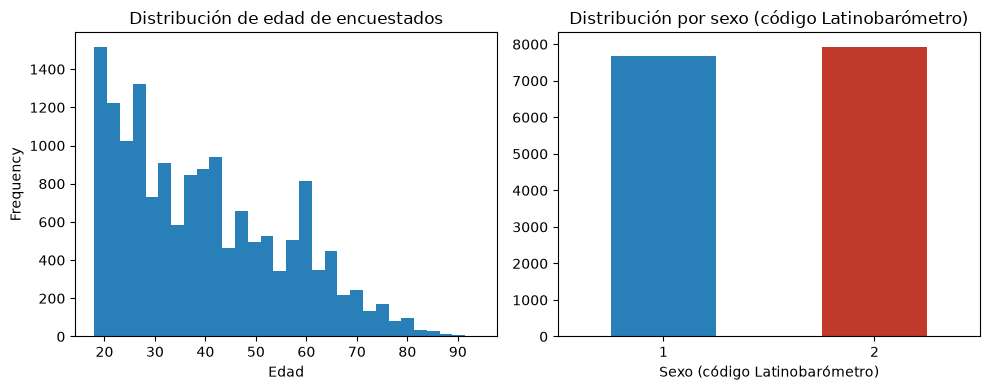

Edad -- estadísticos descriptivos:
count    15600.0
mean        39.7
std         16.1
min         18.0
25%         26.0
50%         37.0
75%         51.0
max         94.0
Name: resp_age, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["resp_age"].plot(kind="hist", bins=30, ax=axes[0], color="#2980b9")
axes[0].set_title("Distribución de edad de encuestados")
axes[0].set_xlabel("Edad")

# resp_sex es float64 (código crudo de Latinobarómetro, 1/2, sin decimales reales),
# así que se convierte el índice a entero antes de graficar -- si no, el eje
# muestra "1.0"/"2.0" en vez de "1"/"2".
conteo_sexo = df["resp_sex"].value_counts().sort_index()
conteo_sexo.index = conteo_sexo.index.astype(int)
conteo_sexo.plot(kind="bar", ax=axes[1], color=["#2980b9", "#c0392b"])
axes[1].set_title("Distribución por sexo (código Latinobarómetro)")
axes[1].set_xlabel("Sexo (código Latinobarómetro)")
plt.setp(axes[1].get_xticklabels(), rotation=0)
fig.tight_layout()
fig.savefig(RUTA_FIGURES / "eda_distribucion_demografica.png", dpi=120)
plt.show()

print("Edad -- estadísticos descriptivos:")
print(df["resp_age"].describe().round(1))

### 4.6 Evolución temporal de los indicadores macro (panel completo 2007-2024)

`panel_macro_anual.csv` tiene un valor por año para TODOS los años 2007-2024 (18 años, ENEMDU+V-Dem no dependen de que Latinobarómetro haya encuestado ese año), a diferencia de `dataset_modelado_personas.csv` que solo tiene las 13 olas reales de encuesta. Esta es la serie que alimenta las ventanas temporales del CNN-LSTM y los rezagos de `rezagos_macro.py`.

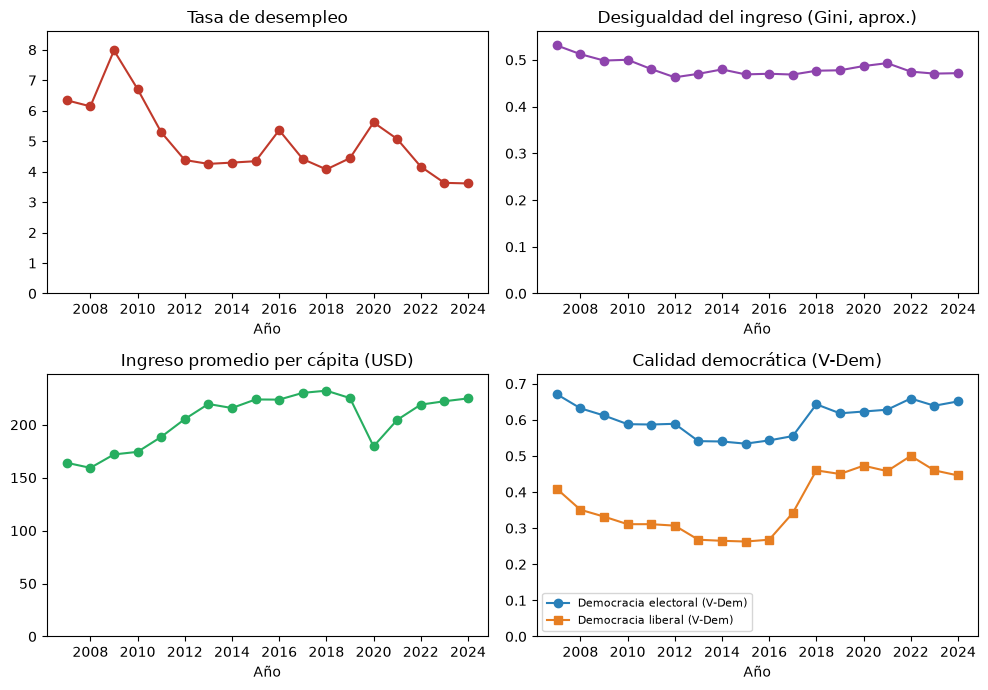

In [7]:
from matplotlib.ticker import MaxNLocator

panel = pd.read_csv(RUTA_PANEL_MACRO)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
panel.plot(x="anio", y="tasa_desempleo", ax=axes[0, 0], marker="o", legend=False, color="#c0392b")
axes[0, 0].set_title("Tasa de desempleo")
panel.plot(x="anio", y="gini_ingpc", ax=axes[0, 1], marker="o", legend=False, color="#8e44ad")
axes[0, 1].set_title("Desigualdad del ingreso (Gini, aprox.)")
panel.plot(x="anio", y="ingreso_promedio_pc", ax=axes[1, 0], marker="o", legend=False, color="#27ae60")
axes[1, 0].set_title("Ingreso promedio per cápita (USD)")
# Nombres descriptivos en la leyenda en vez de los códigos crudos v2x_polyarchy/v2x_libdem.
panel.plot(x="anio", y="v2x_polyarchy", ax=axes[1, 1], marker="o", legend=True, color="#2980b9", label="Democracia electoral (V-Dem)")
panel.plot(x="anio", y="v2x_libdem", ax=axes[1, 1], marker="s", legend=True, color="#e67e22", label="Democracia liberal (V-Dem)")
axes[1, 1].set_title("Calidad democrática (V-Dem)")
axes[1, 1].legend(fontsize=8)

# "anio" es el nombre real de la columna en panel_macro_anual.csv, pero pandas usa ese
# nombre literal como xlabel por defecto -- se corrige a "Año" en las 4 subgráficas, se
# fuerza el eje X a enteros, y además se fuerza el eje Y a iniciar en 0 en las 4
# subgráficas para no exagerar visualmente la magnitud de las variaciones interanuales.
for ax in axes.flat:
    ax.set_xlabel("Año")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    _, ymax = ax.get_ylim()
    ax.set_ylim(0, ymax * 1.05)

fig.tight_layout()
fig.savefig(RUTA_FIGURES / "eda_evolucion_macro.png", dpi=120)
plt.show()


### 4.7 Correlación entre variables numéricas clave y el target

Correlación lineal simple (Pearson) -- no reemplaza a SHAP (que sí captura relaciones no lineales y de interacción, ver `src/evaluation/README.md`), pero es un primer chequeo de sentido común antes de entrenar cualquier modelo.

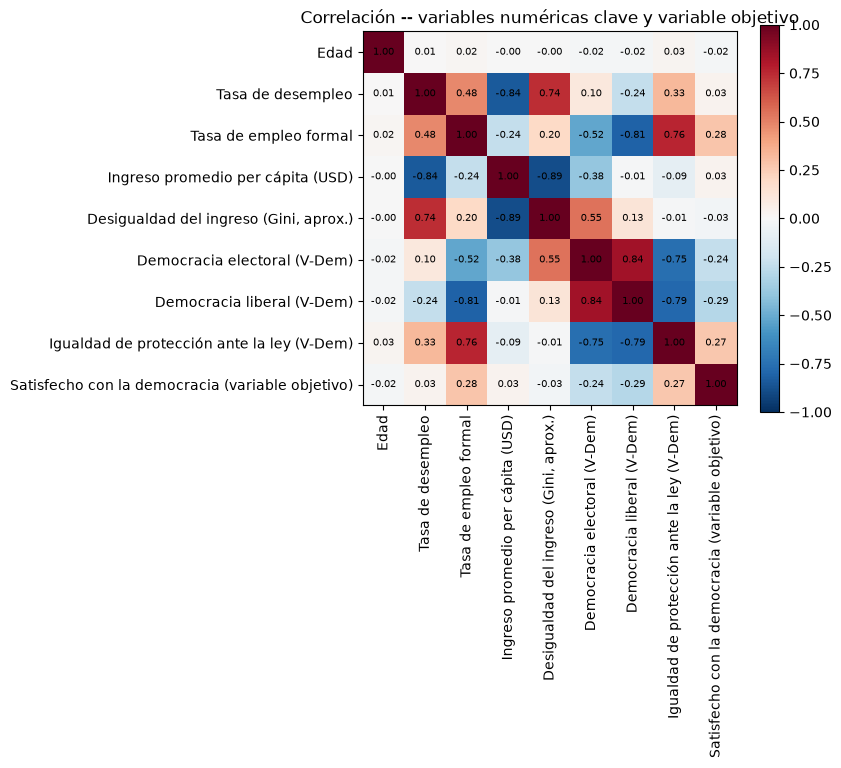

satisfecho_democracia    1.000000
empleo_formal            0.281119
v2xeg_eqprotec           0.269619
tasa_desempleo           0.031821
ingreso_promedio_pc      0.031447
resp_age                -0.018554
gini_ingpc              -0.026398
v2x_polyarchy           -0.240241
v2x_libdem              -0.285399
Name: satisfecho_democracia, dtype: float64


In [8]:
df_valid = df.dropna(subset=["satisfecho_democracia"])
cols_num = [
    "resp_age", "tasa_desempleo", "empleo_formal", "ingreso_promedio_pc", "gini_ingpc",
    "v2x_polyarchy", "v2x_libdem", "v2xeg_eqprotec", "satisfecho_democracia",
]
# Nombres descriptivos para las etiquetas de la matriz (evita mostrar los códigos
# crudos de columna en los ejes).
NOMBRES_CORR = {
    "resp_age": "Edad",
    "tasa_desempleo": "Tasa de desempleo",
    "empleo_formal": "Tasa de empleo formal",
    "ingreso_promedio_pc": "Ingreso promedio per cápita (USD)",
    "gini_ingpc": "Desigualdad del ingreso (Gini, aprox.)",
    "v2x_polyarchy": "Democracia electoral (V-Dem)",
    "v2x_libdem": "Democracia liberal (V-Dem)",
    "v2xeg_eqprotec": "Igualdad de protección ante la ley (V-Dem)",
    "satisfecho_democracia": "Satisfecho con la democracia (variable objetivo)",
}
corr = df_valid[cols_num].corr()
etiquetas = [NOMBRES_CORR[c] for c in cols_num]

fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols_num))); ax.set_xticklabels(etiquetas, rotation=90)
ax.set_yticks(range(len(cols_num))); ax.set_yticklabels(etiquetas)
for i in range(len(cols_num)):
    for j in range(len(cols_num)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im)
ax.set_title("Correlación -- variables numéricas clave y variable objetivo")
fig.tight_layout()
fig.savefig(RUTA_FIGURES / "eda_correlacion_numericas.png", dpi=120)
plt.show()

print(corr["satisfecho_democracia"].sort_values(ascending=False))


### 4.8 Variables categóricas más relevantes (según SHAP) vs. el target

Las 3 variables que encabezan la importancia SHAP global en los 4 modelos (`src/evaluation/README.md`) ya muestran una relación clara y monotónica con el target a nivel puramente descriptivo, sin necesidad de ningún modelo -- una señal de que esa importancia SHAP no es un artefacto, sino que refleja una asociación real en los datos.

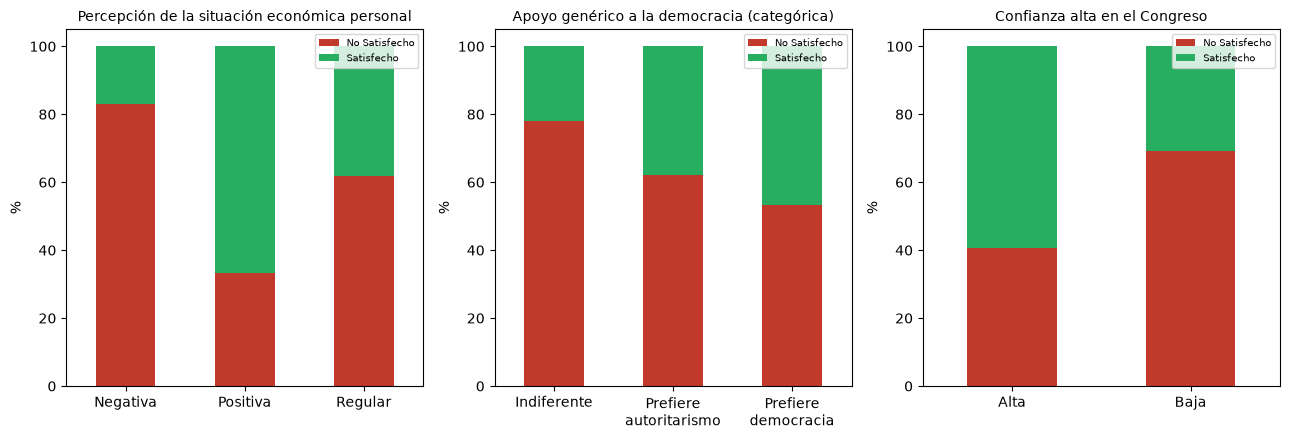

In [9]:
# Nombres descriptivos de las variables (títulos) y de sus valores (evita mezclar
# "True"/"False" en inglés con el resto del texto en español).
TITULOS_CAT = {
    "econ_situation_cat": "Percepción de la situación económica personal",
    "democ_supp_cat": "Apoyo genérico a la democracia (categórica)",
    "confidence_congress_alta": "Confianza alta en el Congreso",
}
ETIQUETAS_VALORES = {
    "econ_situation_cat": {"negativa": "Negativa", "regular": "Regular", "positiva": "Positiva"},
    "democ_supp_cat": {
        "prefiere_democracia": "Prefiere\ndemocracia",
        "indiferente": "Indiferente",
        "prefiere_autoritarismo": "Prefiere\nautoritarismo",
    },
    "confidence_congress_alta": {True: "Alta", False: "Baja"},
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, col in zip(axes, ["econ_situation_cat", "democ_supp_cat", "confidence_congress_alta"]):
    serie_col = df_valid[col].map(ETIQUETAS_VALORES[col])
    tab = pd.crosstab(serie_col, df_valid["satisfecho_democracia"], normalize="index") * 100
    tab.columns = ["No Satisfecho", "Satisfecho"]
    tab.plot(kind="bar", stacked=True, ax=ax, color=["#c0392b", "#27ae60"])
    ax.set_title(TITULOS_CAT[col], fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("%")
    plt.setp(ax.get_xticklabels(), rotation=0)
    ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(RUTA_FIGURES / "eda_categoricas_vs_target.png", dpi=120)
plt.show()


## 5. Resultados

### Conclusiones generales (secciones 4.5 a 4.8)

**Demografía:** edad media 39.7 años (rango 18-94, desviación estándar 16.1), muestra levemente inclinada hacia el código 2 de `resp_sex` (7,930 vs. 7,670 del código 1 -- ver nota sobre la codificación cruda de Latinobarómetro en la sección 4.5).

**Evolución macro (panel completo 2007-2024):** la tasa de desempleo cae de forma sostenida entre 2007 (6.3%) y 2023-2024 (~3.6%), con un repunte visible en 2020 (5.6%, pandemia); el Gini del ingreso baja de 0.53 (2007) a un mínimo de ~0.46 (2012-2015) y se mantiene relativamente estable después; los índices V-Dem (`v2x_polyarchy`, `v2x_libdem`) caen de forma marcada entre 2007 y 2016 (0.67→0.54 y 0.41→0.27), se recuperan a partir de 2018 y llegan a su punto más alto de la serie en 2022 (0.66/0.50).

**Correlación con el target:** a nivel simple (Pearson, sin controlar por año), `empleo_formal` (0.281) y `v2xeg_eqprotec` (0.270) son las variables numéricas más correlacionadas positivamente con "Satisfecho". Un hallazgo que requiere matiz: `v2x_polyarchy` (-0.240) y `v2x_libdem` (-0.285) correlacionan NEGATIVAMENTE con la satisfacción a nivel simple -- contraintuitivo si se piensa en una relación causal directa, pero consistente con que varios de los años de mayor satisfacción (2010, 2011, 2013, 2015, 2017) coinciden con valores de V-Dem más bajos que otros años de la serie; es decir, esta correlación simple mezcla el efecto de la variable con la tendencia temporal común a ambas series, y no debe leerse como "más calidad democrática causa menos satisfacción" -- SHAP (que sí controla por las demás variables y por fold) es la fuente más confiable para atribución de importancia, no esta correlación de un solo cruce.

**Categóricas top-SHAP vs. target:** las 3 variables que SHAP identificó como más importantes en los 4 modelos ya muestran una relación descriptiva clara: "Satisfecho" pasa de 17.1% (percepción económica negativa) a 66.8% (percepción positiva); de 22.0% (indiferente ante la democracia) a 46.6% (prefiere la democracia); y de 30.7% (baja confianza en el Congreso) a 59.4% (alta confianza) -- confirma, con un análisis simple y anterior a cualquier modelo, la misma historia sustantiva que después reportó SHAP.